# Módulo 4 — Python para Preparação dos Dados

## Base PRF 2025 agrupada por ocorrência

Preparação dos dados para análise exploratória, visualização e modelagem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import unicodedata

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


In [ ]:
CWD = Path.cwd().resolve()

if (
    (CWD / "dados").exists()
    and (CWD / "unidade-04-python-preparacao-dados").exists()
):
    RAIZ_REPOSITORIO = CWD

elif (
    (CWD.parent.parent / "dados").exists()
    and
    (CWD.parent.parent / "unidade-04-python-preparacao-dados").exists()
):
    RAIZ_REPOSITORIO = CWD.parent.parent

else:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do repositório "
        "analise-dados-prf-2025."
    )

UNIDADE_04 = (
    RAIZ_REPOSITORIO
    / "unidade-04-python-preparacao-dados"
)

PASTA_DADOS_TRATADOS = UNIDADE_04 / "dados_tratados"
PASTA_DOCUMENTACAO = UNIDADE_04 / "documentacao"

PASTA_DADOS_TRATADOS.mkdir(
    parents=True,
    exist_ok=True
)

PASTA_DOCUMENTACAO.mkdir(
    parents=True,
    exist_ok=True
)

print("Raiz do repositório:", RAIZ_REPOSITORIO)
print("Unidade 04:", UNIDADE_04)

Pastas verificadas/criadas:
- dados_brutos
- dados_tratados
- notebooks
- sql
- dashboards
- relatorios
- apresentacao
- logs


In [ ]:
ARQUIVO_BRUTO = (
    RAIZ_REPOSITORIO
    / "dados"
    / "dados_abertos_prf-datatran2025.csv"
)

ARQUIVO_BASE_ANALITICA = (
    PASTA_DADOS_TRATADOS
    / "base_analitica_prf_2025.csv"
)

ARQUIVO_BASE_MODELAVEL = (
    PASTA_DADOS_TRATADOS
    / "base_modelavel_prf_2025.csv"
)

ARQUIVO_DICIONARIO = (
    PASTA_DADOS_TRATADOS
    / "dicionario_variaveis_modulo4.csv"
)

ARQUIVO_DECISOES = (
    PASTA_DOCUMENTACAO
    / "decisoes_tratamento_modulo4.md"
)

ARQUIVO_README = (
    UNIDADE_04
    / "README.md"
)

SEPARADOR = ";"
ENCODING_ENTRADA = "latin1"
ENCODING_SAIDA = "utf-8-sig"

print("Arquivo bruto:", ARQUIVO_BRUTO)
print("Base analítica:", ARQUIVO_BASE_ANALITICA)
print("Base modelável:", ARQUIVO_BASE_MODELAVEL)
print("Dicionário:", ARQUIVO_DICIONARIO)
print("Documentação:", ARQUIVO_DECISOES)

Arquivo bruto: dados_brutos\acidentes2025.csv
Base analítica: dados_tratados\base_analitica_prf_2025.csv
Base modelável: dados_tratados\base_modelavel_prf_2025.csv


In [4]:
print("Caminho esperado:")
print(ARQUIVO_BRUTO.resolve())

print("\nArquivo existe?")
print(ARQUIVO_BRUTO.exists())

Caminho esperado:
C:\jefferson\projeto_prf_2025\dados_brutos\acidentes2025.csv

Arquivo existe?
True


In [5]:
def ler_csv_prf(
    caminho,
    sep=";",
    encodings=("latin1", "utf-8", "utf-8-sig")
):
    ultimo_erro = None

    for enc in encodings:
        try:
            print(f"Tentando leitura com encoding={enc}...")

            return pd.read_csv(
                caminho,
                sep=sep,
                encoding=enc,
                low_memory=False
            )

        except Exception as erro:
            ultimo_erro = erro
            print(f"Falhou com {enc}: {erro}")

    raise ultimo_erro


df = ler_csv_prf(
    ARQUIVO_BRUTO,
    sep=SEPARADOR
)

df.head()

Tentando leitura com encoding=latin1...


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


In [6]:
df.info(memory_usage="deep")

resumo_tipos = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("tipo")
    .reset_index(name="qtd_colunas")
)

display(resumo_tipos)

<class 'pandas.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      72529 non-null  int64
 1   data_inversa            72529 non-null  str  
 2   dia_semana              72529 non-null  str  
 3   horario                 72529 non-null  str  
 4   uf                      72529 non-null  str  
 5   br                      72529 non-null  int64
 6   km                      72529 non-null  str  
 7   municipio               72529 non-null  str  
 8   causa_acidente          72529 non-null  str  
 9   tipo_acidente           72529 non-null  str  
 10  classificacao_acidente  72528 non-null  str  
 11  fase_dia                72529 non-null  str  
 12  sentido_via             72529 non-null  str  
 13  condicao_metereologica  72529 non-null  str  
 14  tipo_pista              72529 non-null  str  
 15  tracado_via             72529 

,tipo,qtd_colunas
0,str,20
1,int64,10


In [7]:
df.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


In [8]:
def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()

    nome = (
        unicodedata
        .normalize("NFKD", nome)
        .encode("ascii", "ignore")
        .decode("utf-8")
    )

    nome = (
        nome
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

    while "__" in nome:
        nome = nome.replace("__", "_")

    return nome.strip("_")


df.columns = [
    normalizar_nome_coluna(c)
    for c in df.columns
]


# Compatibilização de grafias possíveis
renomear = {
    "condicao_meteorologica": "condicao_metereologica"
}

df = df.rename(
    columns={
        k: v
        for k, v in renomear.items()
        if k in df.columns
    }
)


print("Colunas após padronização:")

for coluna in df.columns:
    print("-", coluna)

Colunas após padronização:
- id
- data_inversa
- dia_semana
- horario
- uf
- br
- km
- municipio
- causa_acidente
- tipo_acidente
- classificacao_acidente
- fase_dia
- sentido_via
- condicao_metereologica
- tipo_pista
- tracado_via
- uso_solo
- pessoas
- mortos
- feridos_leves
- feridos_graves
- ilesos
- ignorados
- feridos
- veiculos
- latitude
- longitude
- regional
- delegacia
- uop


In [9]:
colunas_esperadas = [
    "data_inversa",
    "dia_semana",
    "horario",
    "uf",
    "br",
    "municipio",
    "causa_acidente",
    "tipo_acidente",
    "classificacao_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
    "pessoas",
    "mortos",
    "feridos_leves",
    "feridos_graves",
    "feridos",
    "veiculos"
]


faltantes = [
    c
    for c in colunas_esperadas
    if c not in df.columns
]


print("Quantidade de colunas esperadas:", len(colunas_esperadas))
print("Colunas faltantes:", faltantes)


if faltantes:
    print(
        "\nATENÇÃO: existem colunas esperadas que não foram encontradas."
    )
else:
    print(
        "\nOK — todas as colunas esperadas foram encontradas."
    )

Quantidade de colunas esperadas: 20
Colunas faltantes: []

OK — todas as colunas esperadas foram encontradas.


In [10]:
print("Dimensões da base:", df.shape)

print("Quantidade de linhas:", df.shape[0])

print("Quantidade de colunas:", df.shape[1])


print("\nPrimeiras 5 linhas:")
display(df.head())


print("\nAmostra aleatória de 5 registros:")
display(
    df.sample(
        5,
        random_state=42
    )
)

Dimensões da base: (72529, 30)
Quantidade de linhas: 72529
Quantidade de colunas: 30

Primeiras 5 linhas:


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG



Amostra aleatória de 5 registros:


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,2025-03-15,sábado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminação vermelha do...,Colisão transversal,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Rotatória,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,2025-07-13,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Plena Noite,Decrescente,Céu Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,2025-02-23,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,2025-03-13,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Dupla,Reta,Não,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,2025-02-09,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Declive,Não,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


### Retrato inicial da base

- Quantidade de registros: **72.529**
- Quantidade de colunas: **30**
- A leitura do arquivo ocorreu corretamente.
- A base apresenta uma ocorrência de acidente por registro.

In [11]:
df.info(memory_usage="deep")

resumo_tipos = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("tipo")
    .reset_index(name="qtd_colunas")
)

display(resumo_tipos)

<class 'pandas.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      72529 non-null  int64
 1   data_inversa            72529 non-null  str  
 2   dia_semana              72529 non-null  str  
 3   horario                 72529 non-null  str  
 4   uf                      72529 non-null  str  
 5   br                      72529 non-null  int64
 6   km                      72529 non-null  str  
 7   municipio               72529 non-null  str  
 8   causa_acidente          72529 non-null  str  
 9   tipo_acidente           72529 non-null  str  
 10  classificacao_acidente  72528 non-null  str  
 11  fase_dia                72529 non-null  str  
 12  sentido_via             72529 non-null  str  
 13  condicao_metereologica  72529 non-null  str  
 14  tipo_pista              72529 non-null  str  
 15  tracado_via             72529 

,tipo,qtd_colunas
0,str,20
1,int64,10


In [12]:
nulos = pd.DataFrame({
    "qtd_nulos": df.isna().sum(),
    "perc_nulos": df.isna().mean() * 100
}).sort_values(
    "perc_nulos",
    ascending=False
)

display(
    nulos[nulos["qtd_nulos"] > 0]
)

,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


In [13]:
qtd_duplicadas = df.duplicated().sum()

print(
    "Duplicidades exatas:",
    qtd_duplicadas
)

if qtd_duplicadas > 0:
    df = df.drop_duplicates().copy()

    print(
        "Duplicidades removidas. Nova dimensão:",
        df.shape
    )
else:
    print(
        "Nenhuma duplicidade exata encontrada."
    )

Duplicidades exatas: 0
Nenhuma duplicidade exata encontrada.


### Verificação de duplicidades

Não foram identificadas duplicidades exatas na base.
Nenhum registro foi removido nesta etapa.

In [14]:
categoricas = df.select_dtypes(
    include=["object", "string"]
).columns

cardinalidade = (
    df[categoricas]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .reset_index()
)

cardinalidade.columns = [
    "variavel",
    "qtd_categorias"
]

display(
    cardinalidade.head(30)
)

,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


In [15]:
colunas_numericas = [
    "br",
    "km",
    "pessoas",
    "mortos",
    "feridos",
    "feridos_leves",
    "feridos_graves",
    "ilesos",
    "ignorados",
    "veiculos"
]

for coluna in colunas_numericas:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(
            df[coluna],
            errors="coerce"
        )

print(
    df[
        [c for c in colunas_numericas if c in df.columns]
    ].dtypes
)

br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


In [16]:
df["data_inversa"] = pd.to_datetime(
    df["data_inversa"],
    errors="coerce"
)

df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek

df["fim_de_semana"] = (
    df["dia_semana_num"]
    .isin([5, 6])
    .astype(int)
)

display(
    df[
        [
            "data_inversa",
            "ano",
            "mes",
            "trimestre",
            "dia_semana_num",
            "fim_de_semana"
        ]
    ].head()
)

,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0


In [17]:
horario_limpo = (
    df["horario"]
    .astype(str)
    .str.strip()
)

df["hora"] = pd.to_datetime(
    horario_limpo,
    format="%H:%M:%S",
    errors="coerce"
).dt.hour


# Segunda tentativa para horários no formato HH:MM
faltou_hora = df["hora"].isna()

if faltou_hora.any():
    df.loc[faltou_hora, "hora"] = pd.to_datetime(
        horario_limpo[faltou_hora],
        format="%H:%M",
        errors="coerce"
    ).dt.hour


def classificar_turno(hora):
    if pd.isna(hora):
        return "IGNORADO"

    if 0 <= hora <= 5:
        return "MADRUGADA"

    if 6 <= hora <= 11:
        return "MANHA"

    if 12 <= hora <= 17:
        return "TARDE"

    return "NOITE"


df["turno"] = df["hora"].apply(
    classificar_turno
)

display(
    df[
        [
            "horario",
            "hora",
            "turno"
        ]
    ].head()
)

,horario,hora,turno
0,06:20:00,6,MANHA
1,07:50:00,7,MANHA
2,08:45:00,8,MANHA
3,11:00:00,11,MANHA
4,09:30:00,9,MANHA


In [18]:
display(
    df["turno"]
    .value_counts(dropna=False)
)

turno
TARDE        22302
MANHA        20859
NOITE        20461
MADRUGADA     8907
Name: count, dtype: int64

In [19]:
def criar_faixa_horaria(hora):
    if pd.isna(hora):
        return "IGNORADO"

    inicio = int(hora // 3) * 3
    fim = inicio + 2

    return f"{inicio:02d}h-{fim:02d}h"


df["faixa_horaria"] = df["hora"].apply(
    criar_faixa_horaria
)

display(
    df["faixa_horaria"]
    .value_counts(dropna=False)
    .sort_index()
)

faixa_horaria
00h-02h     3959
03h-05h     4948
06h-08h    11517
09h-11h     9342
12h-14h     9678
15h-17h    12624
18h-20h    13473
21h-23h     6988
Name: count, dtype: int64

In [20]:
colunas_texto = df.select_dtypes(
    include=["object", "string"]
).columns

for coluna in colunas_texto:
    df[coluna] = (
        df[coluna]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    df[coluna] = df[coluna].replace({
        "": pd.NA,
        "NAN": pd.NA,
        "NONE": pd.NA,
        "NULL": pd.NA
    })

print(
    "Colunas textuais padronizadas:",
    len(colunas_texto)
)

Colunas textuais padronizadas: 20


In [21]:
categoricas_importantes = [
    "uf",
    "municipio",
    "causa_acidente",
    "tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
    "classificacao_acidente",
    "dia_semana"
]

categoricas_presentes = [
    c
    for c in categoricas_importantes
    if c in df.columns
]

for coluna in categoricas_presentes:
    df[coluna] = df[coluna].fillna(
        "IGNORADO"
    )

display(
    df[categoricas_presentes]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

uf                        0
municipio                 0
causa_acidente            0
tipo_acidente             0
fase_dia                  0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
classificacao_acidente    0
dia_semana                0
dtype: int64

In [22]:
contagens_vitimas = [
    "mortos",
    "feridos",
    "feridos_leves",
    "feridos_graves",
    "pessoas",
    "veiculos"
]

contagens_presentes = [
    c
    for c in contagens_vitimas
    if c in df.columns
]

for coluna in contagens_presentes:
    df[coluna] = df[coluna].fillna(0)

display(
    df[contagens_presentes]
    .isna()
    .sum()
)

mortos            0
feridos           0
feridos_leves     0
feridos_graves    0
pessoas           0
veiculos          0
dtype: int64

### Tratamento de valores ausentes

- Campos categóricos relevantes foram preenchidos com `IGNORADO`.
- Campos numéricos de contagem foram preenchidos com `0`, conforme a hipótese operacional definida no roteiro.
- A estratégia evita a exclusão de registros e mantém a base disponível para as etapas seguintes.

In [23]:
print("Dimensão atual da base:", df.shape)

print(
    "\nNulos em campos categóricos importantes:"
)

display(
    df[categoricas_presentes]
    .isna()
    .sum()
)

print(
    "\nNulos nas contagens:"
)

display(
    df[contagens_presentes]
    .isna()
    .sum()
)

print(
    "\nAmostra após transformações:"
)

display(
    df[
        [
            "data_inversa",
            "hora",
            "turno",
            "faixa_horaria",
            "uf",
            "municipio",
            "mortos",
            "feridos"
        ]
    ].head()
)

Dimensão atual da base: (72529, 38)

Nulos em campos categóricos importantes:


uf                        0
municipio                 0
causa_acidente            0
tipo_acidente             0
fase_dia                  0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
classificacao_acidente    0
dia_semana                0
dtype: int64


Nulos nas contagens:


mortos            0
feridos           0
feridos_leves     0
feridos_graves    0
pessoas           0
veiculos          0
dtype: int64


Amostra após transformações:


,data_inversa,hora,turno,faixa_horaria,uf,municipio,mortos,feridos
0,2025-01-01,6,MANHA,06H-08H,SP,GUARULHOS,0,1
1,2025-01-01,7,MANHA,06H-08H,CE,PENAFORTE,1,1
2,2025-01-01,8,MANHA,06H-08H,PR,CORNELIO PROCOPIO,0,3
3,2025-01-01,11,MANHA,09H-11H,PR,CAMPINA GRANDE DO SUL,0,1
4,2025-01-01,9,MANHA,09H-11H,MG,FRANCISCO SA,0,2


In [24]:
df["acidente_fatal"] = np.where(
    df["mortos"] >= 1,
    1,
    0
)

validacao_alvo = (
    df["acidente_fatal"]
    .value_counts(dropna=False)
    .rename_axis("acidente_fatal")
    .reset_index(name="qtd")
)

validacao_alvo["perc"] = (
    validacao_alvo["qtd"]
    / validacao_alvo["qtd"].sum()
    * 100
)

display(validacao_alvo)

,acidente_fatal,qtd,perc
0,0,67319,92.816666
1,1,5210,7.183334


In [25]:
violacoes = df.loc[
    (
        (df["mortos"] >= 1)
        & (df["acidente_fatal"] != 1)
    )
    |
    (
        (df["mortos"] == 0)
        & (df["acidente_fatal"] != 0)
    )
]

print(
    "Violações da regra do alvo:",
    len(violacoes)
)

assert len(violacoes) == 0, (
    "Há erro na criação de acidente_fatal."
)

print("OK — variável-alvo criada corretamente.")

Violações da regra do alvo: 0
OK — variável-alvo criada corretamente.


In [26]:
print(
    "Valores existentes em acidente_fatal:",
    sorted(df["acidente_fatal"].unique())
)

assert df["acidente_fatal"].isin([0, 1]).all()

print("OK — o alvo contém apenas 0 e 1.")

Valores existentes em acidente_fatal: [np.int64(0), np.int64(1)]
OK — o alvo contém apenas 0 e 1.


In [27]:
df["total_vitimas"] = (
    df["mortos"]
    + df["feridos_leves"]
    + df["feridos_graves"]
)

df["acidente_grave"] = np.where(
    (df["mortos"] >= 1)
    | (df["feridos_graves"] >= 1),
    1,
    0
)

df["indice_gravidade"] = (
    df["mortos"] * 3
    + df["feridos_graves"] * 2
    + df["feridos_leves"]
)

display(
    df[
        [
            "mortos",
            "feridos_leves",
            "feridos_graves",
            "total_vitimas",
            "acidente_grave",
            "indice_gravidade"
        ]
    ].head()
)

,mortos,feridos_leves,feridos_graves,total_vitimas,acidente_grave,indice_gravidade
0,0,1,0,1,0,1
1,1,1,0,2,1,4
2,0,3,0,3,0,3
3,0,1,0,1,0,1
4,0,1,1,2,1,3


In [28]:
def formatar_br(valor):
    if pd.isna(valor) or valor == 0:
        return "BR-IGNORADA"

    return f"BR-{int(valor):03d}"


df["br_formatada"] = df["br"].apply(
    formatar_br
)

df["chave_localidade"] = (
    df["uf"].astype(str)
    + "_"
    + df["municipio"].astype(str)
    + "_"
    + df["br_formatada"].astype(str)
)

display(
    df[
        [
            "uf",
            "municipio",
            "br",
            "br_formatada",
            "chave_localidade"
        ]
    ].head()
)

,uf,municipio,br,br_formatada,chave_localidade
0,SP,GUARULHOS,116,BR-116,SP_GUARULHOS_BR-116
1,CE,PENAFORTE,116,BR-116,CE_PENAFORTE_BR-116
2,PR,CORNELIO PROCOPIO,369,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,PR,CAMPINA GRANDE DO SUL,116,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,MG,FRANCISCO SA,251,BR-251,MG_FRANCISCO SA_BR-251


In [29]:
checagens = {
    "linhas": len(df),
    "colunas": df.shape[1],

    "acidentes_fatais": int(
        df["acidente_fatal"].sum()
    ),

    "taxa_fatalidade": float(
        df["acidente_fatal"].mean()
    ),

    "total_mortos": int(
        df["mortos"].sum()
    ),

    "total_feridos": (
        int(df["feridos"].sum())
        if "feridos" in df.columns
        else None
    )
}

checagens

{'linhas': 72529,
 'colunas': 44,
 'acidentes_fatais': 5210,
 'taxa_fatalidade': 0.07183333563126473,
 'total_mortos': 6043,
 'total_feridos': 83550}

In [30]:
print(
    "Taxa global de fatalidade:",
    f"{df['acidente_fatal'].mean():.2%}"
)

Taxa global de fatalidade: 7.18%


In [31]:
def ranking_categoria(
    base,
    coluna,
    n=10
):
    return (
        base[coluna]
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(coluna)
        .reset_index(name="qtd")
    )

In [32]:
print("Top 10 causas de acidente:")

display(
    ranking_categoria(
        df,
        "causa_acidente",
        10
    )
)


print("Top 10 tipos de acidente:")

display(
    ranking_categoria(
        df,
        "tipo_acidente",
        10
    )
)

Top 10 causas de acidente:


,causa_acidente,qtd
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413
4,VELOCIDADE INCOMPATÍVEL,4088
5,MANOBRA DE MUDANÇA DE FAIXA,4016
6,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685
7,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385
8,TRANSITAR NA CONTRAMÃO,2475
9,CONDUTOR DORMINDO,2116


Top 10 tipos de acidente:


,tipo_acidente,qtd
0,COLISÃO TRASEIRA,14360
1,SAÍDA DE LEITO CARROÇÁVEL,10209
2,COLISÃO TRANSVERSAL,9306
3,COLISÃO LATERAL MESMO SENTIDO,7885
4,TOMBAMENTO,6351
5,COLISÃO COM OBJETO,5109
6,COLISÃO FRONTAL,4739
7,QUEDA DE OCUPANTE DE VEÍCULO,3450
8,ATROPELAMENTO DE PEDESTRE,3057
9,COLISÃO LATERAL SENTIDO OPOSTO,2152


In [33]:
def taxa_fatal_por_categoria(
    base,
    coluna,
    min_registros=30
):

    tab = (
        base
        .groupby(coluna)
        .agg(
            qtd_acidentes=(
                "acidente_fatal",
                "size"
            ),
            qtd_fatais=(
                "acidente_fatal",
                "sum"
            ),
            taxa_fatal=(
                "acidente_fatal",
                "mean"
            )
        )
        .reset_index()
    )

    tab = tab[
        tab["qtd_acidentes"] >= min_registros
    ]

    return tab.sort_values(
        "taxa_fatal",
        ascending=False
    )

In [34]:
taxa_tipo_acidente = taxa_fatal_por_categoria(
    df,
    "tipo_acidente",
    min_registros=30
)

display(
    taxa_tipo_acidente.head(10)
)

,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal
1,ATROPELAMENTO DE PEDESTRE,3057,902,0.295061
4,COLISÃO FRONTAL,4739,1396,0.294577
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,0.098513
11,EVENTOS ATÍPICOS,287,23,0.080139
0,ATROPELAMENTO DE ANIMAL,1133,68,0.060018
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,0.059261
3,COLISÃO COM OBJETO,5109,297,0.058133
2,CAPOTAMENTO,1373,63,0.045885
7,COLISÃO TRANSVERSAL,9306,427,0.045884
8,COLISÃO TRASEIRA,14360,619,0.043106


In [35]:
taxa_tipo_exibicao = (
    taxa_tipo_acidente
    .head(10)
    .copy()
)

taxa_tipo_exibicao["taxa_fatal_percentual"] = (
    taxa_tipo_exibicao["taxa_fatal"] * 100
)

display(
    taxa_tipo_exibicao[
        [
            "tipo_acidente",
            "qtd_acidentes",
            "qtd_fatais",
            "taxa_fatal_percentual"
        ]
    ]
)

,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal_percentual
1,ATROPELAMENTO DE PEDESTRE,3057,902,29.506052
4,COLISÃO FRONTAL,4739,1396,29.457691
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,9.851301
11,EVENTOS ATÍPICOS,287,23,8.013937
0,ATROPELAMENTO DE ANIMAL,1133,68,6.001765
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,5.926144
3,COLISÃO COM OBJETO,5109,297,5.813271
2,CAPOTAMENTO,1373,63,4.588492
7,COLISÃO TRANSVERSAL,9306,427,4.588438
8,COLISÃO TRASEIRA,14360,619,4.310585


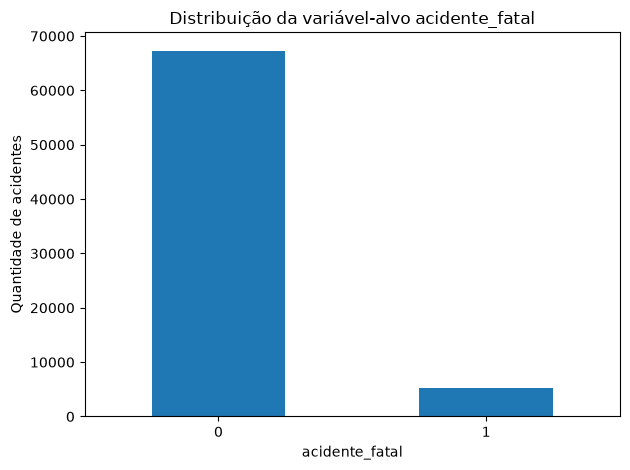

In [36]:
ax = (
    df["acidente_fatal"]
    .value_counts()
    .sort_index()
    .plot(
        kind="bar"
    )
)

ax.set_title(
    "Distribuição da variável-alvo acidente_fatal"
)

ax.set_xlabel(
    "acidente_fatal"
)

ax.set_ylabel(
    "Quantidade de acidentes"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

### Variável-alvo e indicadores de gravidade

A variável `acidente_fatal` foi definida de forma binária:

- `0`: ocorrência sem registro de morte;
- `1`: ocorrência com pelo menos uma morte.

A regra foi validada automaticamente e não foram identificadas violações.

Também foram criados os indicadores:

- `total_vitimas`;
- `acidente_grave`;
- `indice_gravidade`;
- `br_formatada`;
- `chave_localidade`.

Os indicadores derivados do desfecho serão utilizados apenas na base analítica e não deverão compor a base destinada à modelagem.

In [37]:
print("=== VALIDAÇÃO DA SESSÃO 3 ===")

print(
    "\nValores do alvo:",
    sorted(
        df["acidente_fatal"].unique()
    )
)

print(
    "Acidentes fatais:",
    int(
        df["acidente_fatal"].sum()
    )
)

print(
    "Taxa de fatalidade:",
    f"{df['acidente_fatal'].mean():.2%}"
)

print(
    "Violações da regra:",
    len(violacoes)
)

colunas_criadas = [
    "acidente_fatal",
    "total_vitimas",
    "acidente_grave",
    "indice_gravidade",
    "br_formatada",
    "chave_localidade"
]

print("\nVariáveis criadas:")

for coluna in colunas_criadas:
    print(
        coluna,
        "→",
        "OK" if coluna in df.columns else "FALTANDO"
    )

=== VALIDAÇÃO DA SESSÃO 3 ===

Valores do alvo: [np.int64(0), np.int64(1)]
Acidentes fatais: 5210
Taxa de fatalidade: 7.18%
Violações da regra: 0

Variáveis criadas:
acidente_fatal → OK
total_vitimas → OK
acidente_grave → OK
indice_gravidade → OK
br_formatada → OK
chave_localidade → OK


In [38]:
base_analitica = df.copy()

print("Base analítica criada.")
print("Dimensões:", base_analitica.shape)
print("Quantidade de linhas:", base_analitica.shape[0])
print("Quantidade de colunas:", base_analitica.shape[1])

Base analítica criada.
Dimensões: (72529, 44)
Quantidade de linhas: 72529
Quantidade de colunas: 44


In [39]:
variaveis_modelaveis = [
    "uf",
    "br_formatada",
    "municipio",
    "mes",
    "trimestre",
    "dia_semana",
    "dia_semana_num",
    "fim_de_semana",
    "hora",
    "faixa_horaria",
    "turno",
    "fase_dia",
    "causa_acidente",
    "tipo_acidente",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
    "acidente_fatal"
]

variaveis_modelaveis = [
    c
    for c in variaveis_modelaveis
    if c in df.columns
]

base_modelavel = df[
    variaveis_modelaveis
].copy()

print("Base modelável criada.")
print("Dimensões:", base_modelavel.shape)

print("\nVariáveis:")
for coluna in base_modelavel.columns:
    print("-", coluna)

Base modelável criada.
Dimensões: (72529, 19)

Variáveis:
- uf
- br_formatada
- municipio
- mes
- trimestre
- dia_semana
- dia_semana_num
- fim_de_semana
- hora
- faixa_horaria
- turno
- fase_dia
- causa_acidente
- tipo_acidente
- condicao_metereologica
- tipo_pista
- tracado_via
- uso_solo
- acidente_fatal


In [40]:
variaveis_proibidas = [
    "mortos",
    "feridos",
    "feridos_leves",
    "feridos_graves",
    "total_vitimas",
    "indice_gravidade",
    "acidente_grave",
    "classificacao_acidente"
]


def verificar_data_leakage(base, proibidas):

    presentes = [
        c
        for c in proibidas
        if c in base.columns
    ]

    if presentes:
        raise ValueError(
            f"Data leakage detectado: {presentes}"
        )

    return "OK — nenhuma variável proibida encontrada."


resultado_leakage = verificar_data_leakage(
    base_modelavel,
    variaveis_proibidas
)

print(resultado_leakage)

OK — nenhuma variável proibida encontrada.


In [41]:
for coluna in base_modelavel.columns:

    if coluna == "acidente_fatal":
        continue

    if (
        pd.api.types.is_object_dtype(
            base_modelavel[coluna]
        )
        or pd.api.types.is_string_dtype(
            base_modelavel[coluna]
        )
    ):

        base_modelavel[coluna] = (
            base_modelavel[coluna]
            .fillna("IGNORADO")
        )

    else:

        base_modelavel[coluna] = (
            base_modelavel[coluna]
            .fillna(-1)
        )


print("Nulos na base modelável:")

display(
    base_modelavel
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Nulos na base modelável:


uf                        0
br_formatada              0
municipio                 0
mes                       0
trimestre                 0
dia_semana                0
dia_semana_num            0
fim_de_semana             0
hora                      0
faixa_horaria             0
turno                     0
fase_dia                  0
causa_acidente            0
tipo_acidente             0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
acidente_fatal            0
dtype: int64

In [42]:
print("=== VALIDAÇÃO DAS DUAS BASES ===")

print(
    "\nBase analítica:",
    base_analitica.shape
)

print(
    "Base modelável:",
    base_modelavel.shape
)

print(
    "\nMesma quantidade de linhas?",
    len(base_analitica) == len(base_modelavel)
)

print(
    "\nNulos na base modelável:",
    int(base_modelavel.isna().sum().sum())
)

print(
    "\nData leakage:",
    resultado_leakage
)

print(
    "\nAlvo presente?",
    "acidente_fatal" in base_modelavel.columns
)

=== VALIDAÇÃO DAS DUAS BASES ===

Base analítica: (72529, 44)
Base modelável: (72529, 19)

Mesma quantidade de linhas? True

Nulos na base modelável: 0

Data leakage: OK — nenhuma variável proibida encontrada.

Alvo presente? True


In [43]:
base_analitica.to_csv(
    ARQUIVO_BASE_ANALITICA,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

base_modelavel.to_csv(
    ARQUIVO_BASE_MODELAVEL,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

print("Arquivos exportados:")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)

Arquivos exportados:
- dados_tratados\base_analitica_prf_2025.csv
- dados_tratados\base_modelavel_prf_2025.csv


In [44]:
valid_analitica = pd.read_csv(
    ARQUIVO_BASE_ANALITICA,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA,
    low_memory=False
)

valid_modelavel = pd.read_csv(
    ARQUIVO_BASE_MODELAVEL,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA,
    low_memory=False
)

print(
    "Analítica reaberta:",
    valid_analitica.shape
)

print(
    "Modelável reaberta:",
    valid_modelavel.shape
)

assert len(valid_analitica) == len(base_analitica)
assert len(valid_modelavel) == len(base_modelavel)

print(
    "\nOK — arquivos reabertos e quantidade de linhas validada."
)

Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 19)

OK — arquivos reabertos e quantidade de linhas validada.


In [45]:
assert list(valid_analitica.columns) == list(base_analitica.columns), (
    "As colunas da base analítica foram alteradas após a exportação."
)

assert list(valid_modelavel.columns) == list(base_modelavel.columns), (
    "As colunas da base modelável foram alteradas após a exportação."
)

print(
    "OK — linhas e colunas preservadas após exportação."
)

OK — linhas e colunas preservadas após exportação.


In [46]:
linhas_dic = [
    {
        "variavel": "acidente_fatal",
        "descricao": "1 se mortos >= 1; 0 se mortos = 0",
        "uso": "alvo"
    },
    {
        "variavel": "total_vitimas",
        "descricao": "mortos + feridos leves + feridos graves",
        "uso": "analise/dashboard"
    },
    {
        "variavel": "acidente_grave",
        "descricao": "1 se houver morto ou ferido grave; 0 caso contrário",
        "uso": "analise/dashboard"
    },
    {
        "variavel": "indice_gravidade",
        "descricao": "mortos*3 + feridos_graves*2 + feridos_leves",
        "uso": "analise/dashboard"
    },
    {
        "variavel": "br_formatada",
        "descricao": "BR padronizada no formato BR-000",
        "uso": "analise/modelagem"
    },
    {
        "variavel": "chave_localidade",
        "descricao": "UF + município + BR formatada",
        "uso": "analise/dashboard"
    },
    {
        "variavel": "turno",
        "descricao": "MADRUGADA, MANHA, TARDE, NOITE ou IGNORADO",
        "uso": "analise/modelagem"
    },
    {
        "variavel": "faixa_horaria",
        "descricao": "Agrupamento da hora em blocos de 3 horas",
        "uso": "analise/modelagem"
    },
    {
        "variavel": "fim_de_semana",
        "descricao": "1 para sábado/domingo; 0 para demais dias",
        "uso": "analise/modelagem"
    }
]

dicionario = pd.DataFrame(
    linhas_dic
)

dicionario.to_csv(
    ARQUIVO_DICIONARIO,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

display(dicionario)

print(
    "Dicionário criado:",
    ARQUIVO_DICIONARIO
)

,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos leves + feridos graves,analise/dashboard
2,acidente_grave,1 se houver morto ou ferido grave; 0 caso cont...,analise/dashboard
3,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard
4,br_formatada,BR padronizada no formato BR-000,analise/modelagem
5,chave_localidade,UF + município + BR formatada,analise/dashboard
6,turno,"MADRUGADA, MANHA, TARDE, NOITE ou IGNORADO",analise/modelagem
7,faixa_horaria,Agrupamento da hora em blocos de 3 horas,analise/modelagem
8,fim_de_semana,1 para sábado/domingo; 0 para demais dias,analise/modelagem


Dicionário criado: dados_tratados\dicionario_variaveis_modulo4.csv


In [47]:
variaveis_proibidas_dicionario = pd.DataFrame([
    {
        "variavel": "mortos",
        "descricao": "Quantidade de mortos na ocorrência",
        "uso": "PROIBIDA NA MODELAGEM - define diretamente o alvo"
    },
    {
        "variavel": "feridos",
        "descricao": "Quantidade total de feridos",
        "uso": "PROIBIDA NA MODELAGEM - informação associada ao desfecho"
    },
    {
        "variavel": "feridos_leves",
        "descricao": "Quantidade de feridos leves",
        "uso": "PROIBIDA NA MODELAGEM - informação associada ao desfecho"
    },
    {
        "variavel": "feridos_graves",
        "descricao": "Quantidade de feridos graves",
        "uso": "PROIBIDA NA MODELAGEM - informação associada ao desfecho"
    },
    {
        "variavel": "total_vitimas",
        "descricao": "Mortos + feridos leves + feridos graves",
        "uso": "PROIBIDA NA MODELAGEM - derivada do desfecho"
    },
    {
        "variavel": "indice_gravidade",
        "descricao": "Índice calculado a partir de mortos e feridos",
        "uso": "PROIBIDA NA MODELAGEM - derivada do desfecho"
    },
    {
        "variavel": "acidente_grave",
        "descricao": "Indicador baseado em mortos ou feridos graves",
        "uso": "PROIBIDA NA MODELAGEM - derivada do desfecho"
    },
    {
        "variavel": "classificacao_acidente",
        "descricao": "Classificação da gravidade da ocorrência",
        "uso": "PROIBIDA NA MODELAGEM - risco de data leakage"
    }
])

dicionario_completo = pd.concat(
    [dicionario, variaveis_proibidas_dicionario],
    ignore_index=True
)

dicionario_completo.to_csv(
    ARQUIVO_DICIONARIO,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

display(dicionario_completo)

,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos leves + feridos graves,analise/dashboard
2,acidente_grave,1 se houver morto ou ferido grave; 0 caso cont...,analise/dashboard
3,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard
4,br_formatada,BR padronizada no formato BR-000,analise/modelagem
5,chave_localidade,UF + município + BR formatada,analise/dashboard
6,turno,"MADRUGADA, MANHA, TARDE, NOITE ou IGNORADO",analise/modelagem
7,faixa_horaria,Agrupamento da hora em blocos de 3 horas,analise/modelagem
8,fim_de_semana,1 para sábado/domingo; 0 para demais dias,analise/modelagem
9,mortos,Quantidade de mortos na ocorrência,PROIBIDA NA MODELAGEM - define diretamente o alvo


In [48]:
texto_decisoes = f"""
# Decisões de tratamento — Módulo 4

Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Principais decisões

- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com `pd.to_numeric(errors='coerce')`.
- Datas convertidas com `pd.to_datetime(errors='coerce')`.
- Textos padronizados em letras maiúsculas e sem espaços externos.
- Categorias ausentes relevantes preenchidas como `IGNORADO`.
- Valores ausentes em campos de contagem preenchidos com zero conforme hipótese operacional do roteiro.
- Variável-alvo: `acidente_fatal = 1` quando `mortos >= 1`.
- Criados indicadores de gravidade para análise e dashboard.
- Base modelável exclui variáveis diretamente relacionadas ou derivadas do desfecho.
- Nulos numéricos remanescentes na base modelável foram preenchidos com `-1`.
- O arquivo bruto original não foi sobrescrito.

## Arquivos gerados

- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}
"""

ARQUIVO_DECISOES.write_text(
    texto_decisoes,
    encoding="utf-8"
)

print(
    "Arquivo de decisões criado:",
    ARQUIVO_DECISOES
)

Arquivo de decisões criado: logs\decisoes_tratamento_modulo4.md


In [50]:
resumo_final = pd.DataFrame([
    {
        "item": "linhas_base_analitica",
        "valor": len(base_analitica)
    },
    {
        "item": "colunas_base_analitica",
        "valor": base_analitica.shape[1]
    },
    {
        "item": "linhas_base_modelavel",
        "valor": len(base_modelavel)
    },
    {
        "item": "colunas_base_modelavel",
        "valor": base_modelavel.shape[1]
    },
    {
        "item": "acidentes_fatais",
        "valor": int(
            base_modelavel["acidente_fatal"].sum()
        )
    },
    {
        "item": "taxa_global_acidente_fatal",
        "valor": float(
            base_modelavel["acidente_fatal"].mean()
        )
    }
])

display(
    resumo_final
)

,item,valor
0,linhas_base_analitica,72529.000000
1,colunas_base_analitica,44.000000
2,linhas_base_modelavel,72529.000000
3,colunas_base_modelavel,19.000000
4,acidentes_fatais,5210.000000
5,taxa_global_acidente_fatal,0.071833


In [51]:
arquivos_esperados = {
    "Base analítica": ARQUIVO_BASE_ANALITICA,
    "Base modelável": ARQUIVO_BASE_MODELAVEL,
    "Dicionário": ARQUIVO_DICIONARIO,
    "Decisões": ARQUIVO_DECISOES,
    "README": ARQUIVO_README
}

print("=== ARQUIVOS FINAIS ===")

todos_ok = True

for nome, caminho in arquivos_esperados.items():

    existe = caminho.exists()

    print(
        f"{nome}:",
        "OK" if existe else "FALTANDO",
        "→",
        caminho
    )

    if not existe:
        todos_ok = False


if todos_ok:
    print(
        "\nOK — todos os arquivos finais foram gerados."
    )
else:
    print(
        "\nATENÇÃO — existem arquivos faltando."
    )

=== ARQUIVOS FINAIS ===
Base analítica: OK → dados_tratados\base_analitica_prf_2025.csv
Base modelável: OK → dados_tratados\base_modelavel_prf_2025.csv
Dicionário: OK → dados_tratados\dicionario_variaveis_modulo4.csv
Decisões: OK → logs\decisoes_tratamento_modulo4.md
README: OK → README.md

OK — todos os arquivos finais foram gerados.


In [52]:
campos_power_bi = [
    "uf",
    "br_formatada",
    "municipio",
    "mes"
]

faltantes_power_bi = [
    c
    for c in campos_power_bi
    if c not in base_analitica.columns
]

print("Campos necessários para filtros do Power BI:")

for campo in campos_power_bi:
    print(
        campo,
        "→",
        "OK" if campo in base_analitica.columns else "FALTANDO"
    )

assert not faltantes_power_bi, (
    f"Campos faltantes para Power BI: {faltantes_power_bi}"
)

print("\nOK — base analítica possui os campos necessários.")

Campos necessários para filtros do Power BI:
uf → OK
br_formatada → OK
municipio → OK
mes → OK

OK — base analítica possui os campos necessários.


In [53]:
print("=== CONFERÊNCIA DA BASE MODELÁVEL ===")

print("Quantidade de variáveis:", base_modelavel.shape[1])

print("\nVariáveis presentes:")

for coluna in base_modelavel.columns:
    print("-", coluna)

assert "acidente_fatal" in base_modelavel.columns

verificar_data_leakage(
    base_modelavel,
    variaveis_proibidas
)

print(
    "\nOK — a base contém variáveis explicativas "
    "e o alvo acidente_fatal, sem variáveis proibidas."
)

=== CONFERÊNCIA DA BASE MODELÁVEL ===
Quantidade de variáveis: 19

Variáveis presentes:
- uf
- br_formatada
- municipio
- mes
- trimestre
- dia_semana
- dia_semana_num
- fim_de_semana
- hora
- faixa_horaria
- turno
- fase_dia
- causa_acidente
- tipo_acidente
- condicao_metereologica
- tipo_pista
- tracado_via
- uso_solo
- acidente_fatal

OK — a base contém variáveis explicativas e o alvo acidente_fatal, sem variáveis proibidas.


# Encerramento do Módulo 4

## Autoavaliação da entrega

- **Correção técnica:** o notebook executa integralmente sem erros.
- **Reprodutibilidade:** o kernel foi reiniciado e todas as células foram executadas em sequência.
- **Documentação:** foram gerados README, dicionário de variáveis e registro das decisões de tratamento.
- **Separação das bases:** foram produzidas bases analítica e modelável com finalidades distintas.
- **Prevenção de vazamento:** as variáveis relacionadas diretamente ao desfecho foram excluídas da base modelável.

## Perguntas para análise exploratória — Módulo 5

1. Quais tipos de acidente apresentam as maiores taxas de fatalidade?
2. Como a ocorrência de acidentes fatais varia entre turnos e faixas horárias?
3. Quais BRs, municípios ou estados concentram maior quantidade e maior proporção de acidentes fatais?

## Preparação para os próximos módulos

A base analítica será utilizada na análise exploratória e no Power BI.

A base modelável será utilizada posteriormente na construção de uma árvore de decisão, sem utilização de variáveis que provoquem data leakage.